# CRIMES ANALYSIS
En este notebook se va a documentar los procesos necesarios al dataset

## ¿DE QUE TRATA EL DATASET?
Este dataset guarda informacion de **151340** casos de crimentes sucedidos en Los Angeles, revelando informacion relevante sobre estos desde **informacion** de la **victima** hasta el contexto del crimen, **que armas** se usaron, **que delito/s** se llevaron a cabo, **donde** sucedio exactamente, etc....

# 1. Importe de librerias

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
# Configuración básica
plt.rcParams['figure.figsize'] = (8,5)
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


# 2. Carga del Dataset

## URL de dataset:
 * #### https://www.kaggle.com/datasets/venkatsairo4899/los-angeles-crime-data-2020-2023?select=Crime_Data_from_2020_to_Present.csv


In [42]:
#Creacion de subconjuntos
ruta = "..\\data\\Crime_Data_from_2020_to_Present.csv"
# df = pd.read_csv(ruta)
# df_filtrado_no_investigados = df[df['Status Desc'] != 'Invest Cont'].copy()
# df_filtrado_no_investigados.to_csv('..\\data\\Dataset_crimes_not_invest.csv', index=False)
# df_filtrado_investigados = df[df['Status Desc'] == 'Invest Cont'].copy()
# df_filtrado_investigados.to_csv('..\\data\\Dataset_crimes_invest.csv', index=False)

# ruta = "..\\data\\Dataset_crimes_not_invest.csv"
df = pd.read_csv(ruta)
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,10304468,01/08/2020 12:00:00 AM,01/08/2020 12:00:00 AM,2230,3,Southwest,377,2,624,BATTERY - SIMPLE ASSAULT,...,AO,Adult Other,624.0,NaN,NaN,NaN,1100 W 39TH PL,NaN,34.0141,-118.2978
1,190101086,01/02/2020 12:00:00 AM,01/01/2020 12:00:00 AM,330,1,Central,163,2,624,BATTERY - SIMPLE ASSAULT,...,IC,Invest Cont,624.0,NaN,NaN,NaN,700 S HILL ST,NaN,34.0459,-118.2545
2,200110444,04/14/2020 12:00:00 AM,02/13/2020 12:00:00 AM,1200,1,Central,155,2,845,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,...,AA,Adult Arrest,845.0,NaN,NaN,NaN,200 E 6TH ST,NaN,34.0448,-118.2474
3,191501505,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,1730,15,N Hollywood,1543,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,998.0,NaN,NaN,5400 CORTEEN PL,NaN,34.1685,-118.4019
4,191921269,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,415,19,Mission,1998,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",...,IC,Invest Cont,740.0,NaN,NaN,NaN,14400 TITUS ST,NaN,34.2198,-118.4468


In [2]:
# df["Status Desc"]=df["Status Desc"].map(
#     {
#     "Adult Arrest":1,
#     "Juv Arrest":1, 
#     "Adult Other":0, 
#     "Juv Other":0
#     })
# # # df["Status Desc"]=df["Status Desc"].astype(int)
df=df.dropna(subset=["Status Desc"])
df["Status Desc"].isnull().sum()
# # df["Status Desc"].value_counts()
# df.shape

NameError: name 'df' is not defined

In [52]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,10304468,01/08/2020 12:00:00 AM,01/08/2020 12:00:00 AM,2230,3,Southwest,377,2,624,BATTERY - SIMPLE ASSAULT,...,AO,0.0,624.0,NaN,NaN,NaN,1100 W 39TH PL,NaN,34.0141,-118.2978
2,200110444,04/14/2020 12:00:00 AM,02/13/2020 12:00:00 AM,1200,1,Central,155,2,845,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,...,AA,1.0,845.0,NaN,NaN,NaN,200 E 6TH ST,NaN,34.0448,-118.2474
9,201710201,06/19/2020 12:00:00 AM,05/26/2020 12:00:00 AM,1925,17,Devonshire,1708,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,AO,0.0,341.0,NaN,NaN,NaN,11900 BALBOA BL,NaN,34.2864,-118.5021
12,200100514,01/05/2020 12:00:00 AM,01/05/2020 12:00:00 AM,1355,1,Central,162,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,AA,1.0,341.0,NaN,NaN,NaN,800 S OLIVE ST,NaN,34.0452,-118.2569
16,201116159,11/29/2020 12:00:00 AM,11/28/2020 12:00:00 AM,2018,11,Northeast,1124,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,AO,0.0,626.0,NaN,NaN,NaN,3200 W AVENUE 32,NaN,34.1186,-118.2450


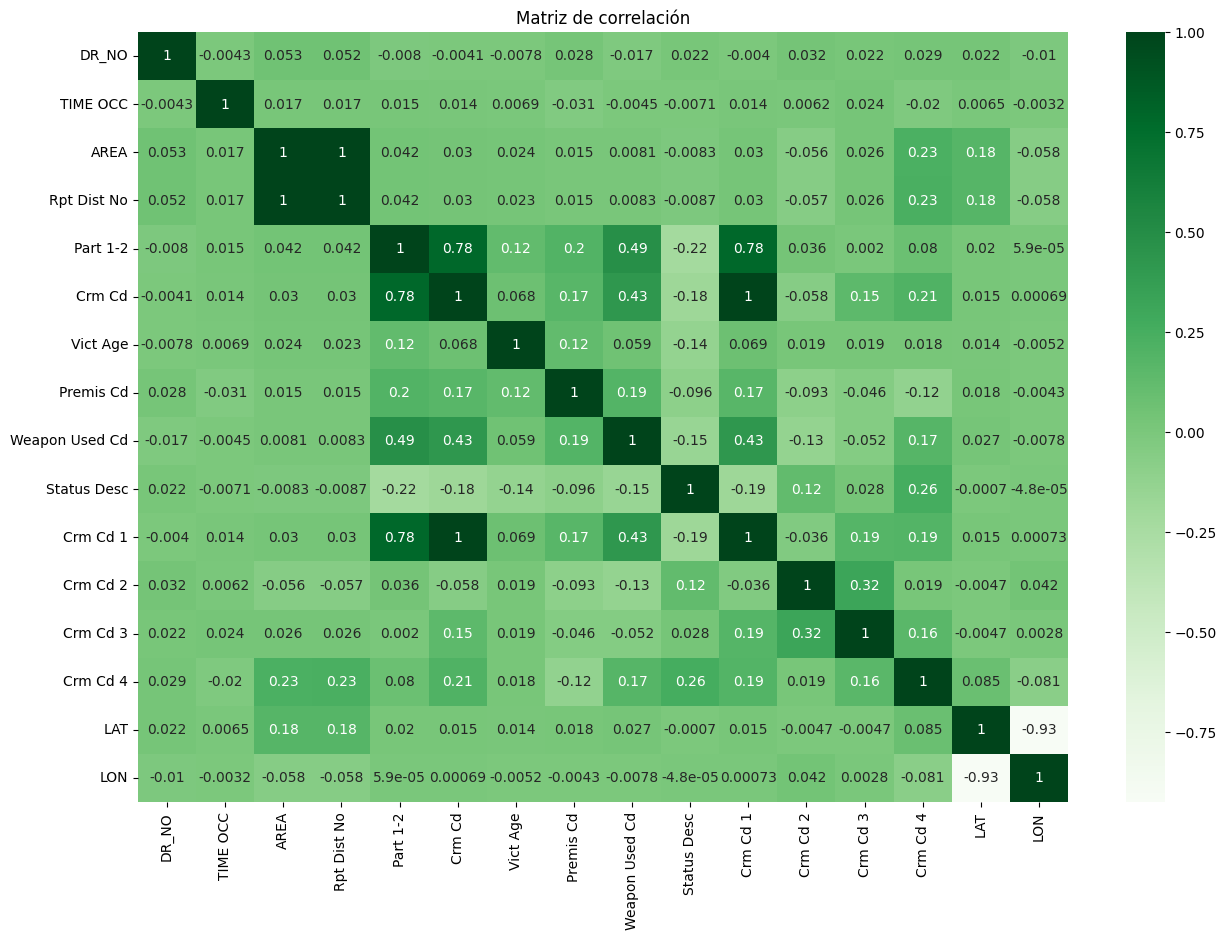

In [53]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap="Greens")

plt.title("Matriz de correlación")

plt.show()

# 3. Exploracion Inicial del Dataset

### tamaño de Dataset

In [12]:
df.shape

(757141, 28)

### informacion del dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 757141 entries, 0 to 757140
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DR_NO           757141 non-null  int64  
 1   Date Rptd       757141 non-null  str    
 2   DATE OCC        757141 non-null  str    
 3   TIME OCC        757141 non-null  int64  
 4   AREA            757141 non-null  int64  
 5   AREA NAME       757141 non-null  str    
 6   Rpt Dist No     757141 non-null  int64  
 7   Part 1-2        757141 non-null  int64  
 8   Crm Cd          757141 non-null  int64  
 9   Crm Cd Desc     757141 non-null  str    
 10  Mocodes         653226 non-null  str    
 11  Vict Age        757141 non-null  int64  
 12  Vict Sex        658230 non-null  str    
 13  Vict Descent    658224 non-null  str    
 14  Premis Cd       757132 non-null  float64
 15  Premis Desc     756699 non-null  str    
 16  Weapon Used Cd  263079 non-null  float64
 17  Weapon Desc     26307

### descripcion detallada de Dataset

In [5]:
df.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,7.571410e+05,757141.000000,757141.000000,757141.000000,757141.000000,757141.000000,757141.000000,757132.000000,263079.000000,757131.000000,56016.000000,1872.000000,56.000000,757141.000000,757141.000000
mean,2.148771e+08,1334.814871,10.718368,1118.245674,1.415613,500.847668,29.909412,305.938960,362.590230,500.589136,957.298861,983.676282,990.232143,33.971554,-117.999799
std,1.033130e+07,653.847053,6.092302,609.235556,0.492828,207.952490,21.731307,216.793004,123.737617,207.743554,111.871937,51.356926,28.834317,1.864571,6.465919
min,8.170000e+02,1.000000,1.000000,101.000000,1.000000,110.000000,-2.000000,101.000000,101.000000,110.000000,210.000000,434.000000,821.000000,0.000000,-118.667600
25%,2.021135e+08,900.000000,6.000000,622.000000,1.000000,331.000000,11.000000,101.000000,309.000000,331.000000,998.000000,998.000000,998.000000,34.013300,-118.429500
50%,2.119136e+08,1415.000000,11.000000,1142.000000,1.000000,442.000000,31.000000,203.000000,400.000000,442.000000,998.000000,998.000000,998.000000,34.058400,-118.321400
75%,2.215089e+08,1900.000000,16.000000,1618.000000,2.000000,626.000000,45.000000,501.000000,400.000000,626.000000,998.000000,998.000000,998.000000,34.163100,-118.273900
max,2.399165e+08,2359.000000,21.000000,2199.000000,2.000000,956.000000,120.000000,974.000000,516.000000,956.000000,999.000000,999.000000,999.000000,34.334300,0.000000


# 4.Filtro de datos
Categorias a usar

## Seleccion Columnas
el dataset contiene las siguientes variables:
* **DR_NO:** int64  
* **Date Rptd:** str    
* **DATE OCC:** str    
* **TIME OCC:** int64  
* **AREA:** int64  
* **AREA NAME:** str    
* **Rpt Dist No:** int64  
* **Part 1-2:** int64  
* **Crm Cd:** int64  
* **Crm Cd Desc:** str    
* **Mocodes:** str    
* **Vict Age:** int64  
* **Vict Sex:** str    
* **Vict Descent:** str    
* **Premis Cd:** float64
* **Premis Desc:** str    
* **Weapon Used Cd:** float64
* **Weapon Desc:** str    
* **Status:** str    
* **Status Desc:** str    
* **Crm Cd 1:** float64
* **Crm Cd 2:** float64
* **Crm Cd 3:** float64
* **Crm Cd 4:** float64
* **LOCATION:** str    
* **Cross Street:** str    
* **LAT:** float64
* **LON:** float64

y se ha decidido que las mas importantes son:
* **DR_NO:** representa info acerca del numero de caso, es decir, es el indice.
* **TIME OCC:** representa info acerca de la hora en formato militar.
* **DATE OCC:** representa info acerca de la fecha del crimen.
* **AREA NAME:** representa info acerca del barrio donde sucedio el crimen.
* **Crm Cd Desc:** representa info acerca de la descripcion del primer delito del caso
* **Crm Cd 2:** representa info acerca del codigo de delito del segundo delito del caso.
* **Crm Cd 3:** representa info acerca del codigo de delito del tercer delito del caso. 
* **Crm Cd 4:** representa info acerca del codigo de delito del cuarto delito del caso.
* **Vict Age:** representa info acerca de la edad de la victima.
* **Vict Sex:** representa info acerca del genero de la victima.
* **Vict Descent:** representa info acerca de la descendencia de la victima, es decir, si el blanco, hispano, asiatico, etc....
* **Premis Desc:** representa info acerca de la ubicacion del crimen mas concretamente en que tipo de ubicacion, por ejemplo: hotel, mini-mart, hospital, street, etc..
* **Weapon Desc:** representa info acerca del tipo de arma usada, por ejemplo: knife, stick, hand gun, strong-arm.
* **Status Desc:** representa info acerca de si el acusado ha sido arrestado o si el caso sigue en investigacion.
* **Part 1-2:** representa info acerca de la gravedad del caso siendo el 2 un delito menos agravante que el 1.
* **LOCATION:** representa info acerca de la direccion de la calle donde sucedio el crimen.

In [10]:
df["Vict Sex"].value_counts()

Vict Sex
M    313598
F    279785
X     64759
H        87
-         1
Name: count, dtype: int64

In [43]:
df["Vict Sex"]=df["Vict Sex"].map(
    {
    "M":1,
    "F":2, 
    "X":0,
    })

In [44]:
df["Vict Sex"]=df["Vict Sex"].fillna(0)

In [45]:
df["Vict Sex"].isnull().sum()

np.int64(0)

In [48]:
df["Vict Descent"].value_counts()

Vict Descent
1.0     232578
2.0     155242
3.0     108667
0.0      71785
4.0      59910
5.0      16531
6.0       4031
7.0       3155
8.0       2846
9.0       1062
10.0       766
11.0       722
12.0       370
13.0       207
14.0       157
15.0        52
16.0        51
17.0        47
18.0        43
Name: count, dtype: int64

In [47]:
df["Vict Descent"]=df["Vict Descent"].map(
    {
"X":0,
"H":1,
"W":2,
"B":3,
"O":4,
"A":5,
"K":6,
"F":7,
"C":8,
"J":9,
"V":10,
"I":11,
"Z":12,
"P":13,
"U":14,
"D":15,
"G":16,
"L":17,
"S":18
    })

In [51]:
df["Vict Descent"].isnull().sum()


np.int64(0)

In [50]:
df["Vict Descent"]=df["Vict Descent"].fillna(0)

In [3]:
ColumnasAUsar=df[["DR_NO", "TIME OCC", "DATE OCC", "AREA NAME", "Crm Cd Desc","Crm Cd 2","Crm Cd 3","Crm Cd 4", "Vict Age", "Vict Sex", "Vict Descent","Premis Desc", "Weapon Desc", "Status Desc", "Part 1-2","LOCATION"]]
ColumnasAUsar.head()

,DR_NO,TIME OCC,DATE OCC,AREA NAME,Crm Cd Desc,Crm Cd 2,Crm Cd 3,Crm Cd 4,Vict Age,Vict Sex,Vict Descent,Premis Desc,Weapon Desc,Status Desc,Part 1-2,LOCATION
0,10304468,2230,01/08/2020 12:00:00 AM,Southwest,BATTERY - SIMPLE ASSAULT,NaN,NaN,NaN,36,F,B,SINGLE FAMILY DWELLING,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",Adult Other,2,1100 W 39TH PL
1,190101086,330,01/01/2020 12:00:00 AM,Central,BATTERY - SIMPLE ASSAULT,NaN,NaN,NaN,25,M,H,SIDEWALK,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,2,700 S HILL ST
2,200110444,1200,02/13/2020 12:00:00 AM,Central,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,NaN,NaN,NaN,0,X,X,POLICE FACILITY,NaN,Adult Arrest,2,200 E 6TH ST
3,191501505,1730,01/01/2020 12:00:00 AM,N Hollywood,VANDALISM - MISDEAMEANOR ($399 OR UNDER),998.0,NaN,NaN,76,F,W,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,Invest Cont,2,5400 CORTEEN PL
4,191921269,415,01/01/2020 12:00:00 AM,Mission,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",NaN,NaN,NaN,31,X,X,BEAUTY SUPPLY STORE,NaN,Invest Cont,2,14400 TITUS ST


In [52]:
df["Status Desc"]=df["Status Desc"].map(
    {
    "Adult Arrest":2,
    "Juv Arrest":2, 
    "Adult Other":1, 
    "Juv Other":1
    })
df["Status Desc"]=df["Status Desc"].fillna(0)
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,10304468,01/08/2020 12:00:00 AM,01/08/2020 12:00:00 AM,2230,3,Southwest,377,2,624,BATTERY - SIMPLE ASSAULT,...,AO,1.0,624.0,NaN,NaN,NaN,1100 W 39TH PL,NaN,34.0141,-118.2978
1,190101086,01/02/2020 12:00:00 AM,01/01/2020 12:00:00 AM,330,1,Central,163,2,624,BATTERY - SIMPLE ASSAULT,...,IC,0.0,624.0,NaN,NaN,NaN,700 S HILL ST,NaN,34.0459,-118.2545
2,200110444,04/14/2020 12:00:00 AM,02/13/2020 12:00:00 AM,1200,1,Central,155,2,845,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,...,AA,2.0,845.0,NaN,NaN,NaN,200 E 6TH ST,NaN,34.0448,-118.2474
3,191501505,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,1730,15,N Hollywood,1543,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,0.0,745.0,998.0,NaN,NaN,5400 CORTEEN PL,NaN,34.1685,-118.4019
4,191921269,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,415,19,Mission,1998,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",...,IC,0.0,740.0,NaN,NaN,NaN,14400 TITUS ST,NaN,34.2198,-118.4468


In [53]:
df["Status Desc"].value_counts()

Status Desc
0.0    605804
1.0     82799
2.0     68538
Name: count, dtype: int64

# Premiss Cd

In [54]:
df["Premis Cd"]=df["Premis Cd"].fillna(0)

# Weapon Used Cd

In [55]:
df["Weapon Used Cd"]=df["Weapon Used Cd"].fillna(0)

# Crm Cd 1

In [56]:
df["Crm Cd 1"]=df["Crm Cd 1"].fillna(0)

# Crm Cd 2

In [57]:
df["Crm Cd 2"]=df["Crm Cd 2"].fillna(0)

# Crm Cd 3

In [58]:
df["Crm Cd 3"]=df["Crm Cd 3"].fillna(0)

# Crm Cd 4

In [59]:
df["Crm Cd 4"]=df["Crm Cd 4"].fillna(0)

In [24]:
ColumnasAUsar.shape

(151337, 16)

In [60]:
df.isnull().sum()

DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   0
AREA NAME              0
Rpt Dist No            0
Part 1-2               0
Crm Cd                 0
Crm Cd Desc            0
Mocodes           103915
Vict Age               0
Vict Sex               0
Vict Descent           0
Premis Cd              0
Premis Desc          442
Weapon Used Cd         0
Weapon Desc       494062
Status                 0
Status Desc            0
Crm Cd 1               0
Crm Cd 2               0
Crm Cd 3               0
Crm Cd 4               0
LOCATION               0
Cross Street      635409
LAT                    0
LON                    0
dtype: int64

In [61]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,10304468,01/08/2020 12:00:00 AM,01/08/2020 12:00:00 AM,2230,3,Southwest,377,2,624,BATTERY - SIMPLE ASSAULT,...,AO,1.0,624.0,0.0,0.0,0.0,1100 W 39TH PL,NaN,34.0141,-118.2978
1,190101086,01/02/2020 12:00:00 AM,01/01/2020 12:00:00 AM,330,1,Central,163,2,624,BATTERY - SIMPLE ASSAULT,...,IC,0.0,624.0,0.0,0.0,0.0,700 S HILL ST,NaN,34.0459,-118.2545
2,200110444,04/14/2020 12:00:00 AM,02/13/2020 12:00:00 AM,1200,1,Central,155,2,845,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,...,AA,2.0,845.0,0.0,0.0,0.0,200 E 6TH ST,NaN,34.0448,-118.2474
3,191501505,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,1730,15,N Hollywood,1543,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,0.0,745.0,998.0,0.0,0.0,5400 CORTEEN PL,NaN,34.1685,-118.4019
4,191921269,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,415,19,Mission,1998,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",...,IC,0.0,740.0,0.0,0.0,0.0,14400 TITUS ST,NaN,34.2198,-118.4468


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 757141 entries, 0 to 757140
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DR_NO           757141 non-null  int64  
 1   Date Rptd       757141 non-null  str    
 2   DATE OCC        757141 non-null  str    
 3   TIME OCC        757141 non-null  int64  
 4   AREA            757141 non-null  int64  
 5   AREA NAME       757141 non-null  str    
 6   Rpt Dist No     757141 non-null  int64  
 7   Part 1-2        757141 non-null  int64  
 8   Crm Cd          757141 non-null  int64  
 9   Crm Cd Desc     757141 non-null  str    
 10  Mocodes         653226 non-null  str    
 11  Vict Age        757141 non-null  int64  
 12  Vict Sex        757141 non-null  float64
 13  Vict Descent    757141 non-null  float64
 14  Premis Cd       757141 non-null  float64
 15  Premis Desc     756699 non-null  str    
 16  Weapon Used Cd  757141 non-null  float64
 17  Weapon Desc     26307

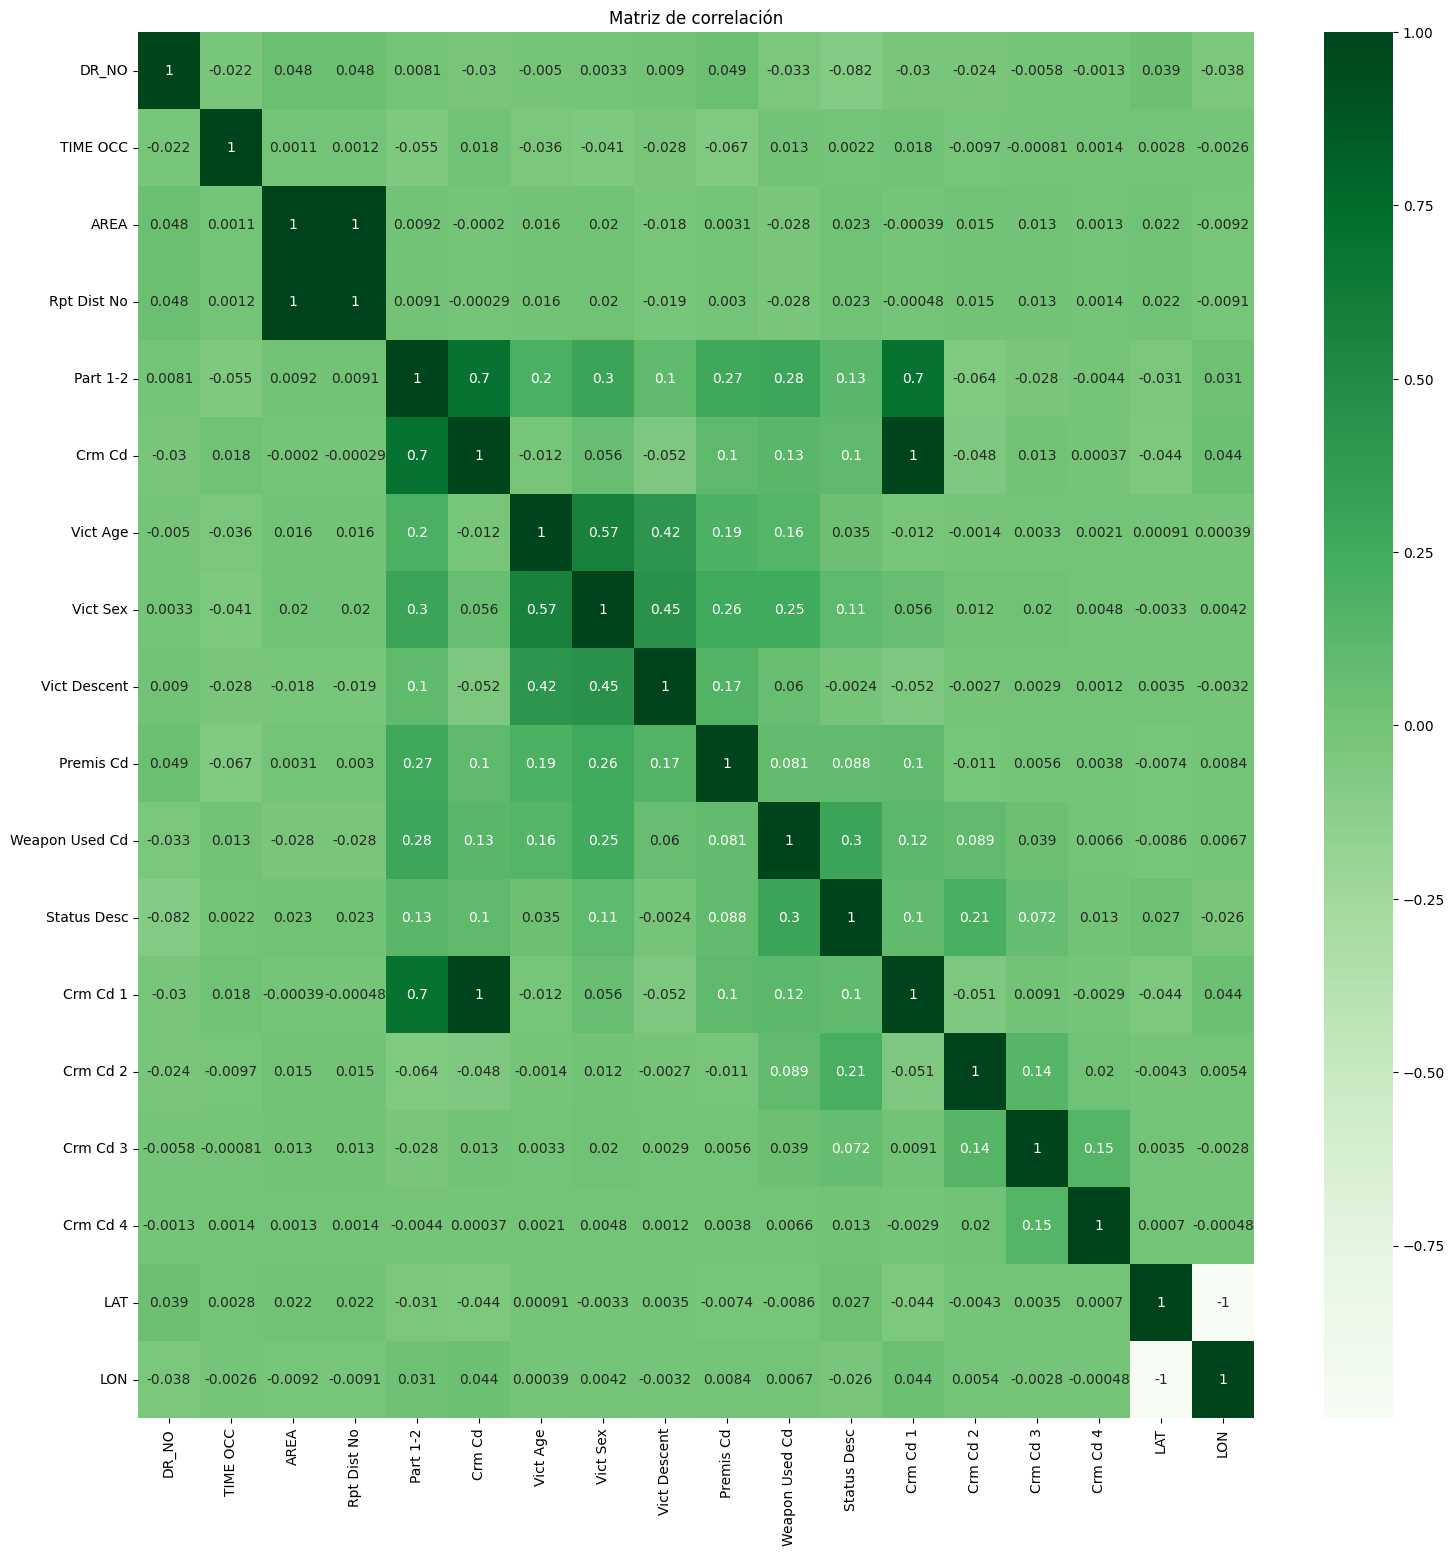

In [63]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(18,18))
sns.heatmap(corr, annot=True, cmap="Greens")

plt.title("Matriz de correlación")

plt.show()

In [64]:
df.to_csv("..\\data\\crimeData_subconjunto.csv")